In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

In [40]:
Om = 0.3
H0 = 73
q0 = -0.55
j0 = 1
s0 = -0.35
c = 299792.458#km/s
z = np.linspace(0,5, 2000)

In [80]:
def Ez(z, theta):
    H0, Om = theta
    return np.sqrt(Om*(1+z)**3+1-Om)

def DcLCDM(z, theta):
    dc = np.zeros_like(z)

    ez = lambda z2, theta: 1/Ez(z2, theta)
    
    for i in range(len(z)):
        if i == 0:
            dc[i], _ = quad(ez, 0, z[i], args=(theta), epsabs=1e-05, epsrel=1e-05)
            if not np.isfinite(dc[i]):
                dc[i] = np.inf
        else:
            dc_aux, _ = quad(ez, z[i-1], z[i], args=(theta), epsabs=1e-05, epsrel=1e-05)
            dc[i] = dc_aux + dc[i-1]
            if not np.isfinite(dc[i]):
                dc[i] = np.inf
    return (c/H0)*dc

In [81]:
def EzP21(z, theta):
    H0, q0, j0 = theta

    a1 = 1/H0
    a2 = (1 -2 * j0 + 2 * q0 + 3 * (q0 ** 2))/(6*H0*(1 + q0))
    b1 = (2 -j0 + 4 * q0 + 3 * (q0 ** 2))/(3*(1 + q0))

    hz = ((1 + b1 * z) ** 2) / (a1 + a2 * z * (2 + b1 * z))

    return hz

def EzP22(z, theta):
    H0, q0, j0, s0 = theta
    
    a1 = 1/H0
    a2 = ((-1 + 5 * j0 -3 * q0 + 6 * j0 * q0 -8 * (q0 ** 2) -6 * (q0 ** 3) + s0)) / (2*H0*((-1 + 2 * j0 -2 * q0 -3 * (q0 ** 2))))
    b1 = ((-2 + 7 * j0 -6 * q0 + 8 * j0 * q0 -13 * (q0 ** 2) -9 * (q0 ** 3) + s0)) /(2*(-1 + 2 * j0 -2 * q0 -3 * (q0 ** 2)))
    b2 = (2 -11 * j0 -4 * (j0 ** 2) + 8 * q0 -25 * j0 * q0 + 23 * (q0 ** 2) -6 * j0 * (q0 ** 2) + 30 * (q0 ** 3) + 9 * (q0 ** 4) -3 * s0
          -3 * q0 *s0) / (12 -24 * j0 + 24 * q0 + 36 * (q0 ** 2))

    hz = ((1 + b1 * z + b2 * (z ** 2)) ** 2) / (a1 -(a1 * b2 * (z ** 2)) + a2 *z * (2 + b1 * z))

    return hz/H0

def EzP31(z, theta):
    H0, q0, j0, s0 = theta

    a1 = 1/H0
    a2 = ((-2 + 7 * j0 -6 * q0 + 8 * j0 * q0 -13 * (q0 ** 2) -9 * (q0 **3) + s0))/(4*H0*(-2 + j0 -4 * q0 -3 * (q0 ** 2)))
    a3 = ((2 -11 * j0 -4 * (j0 ** 2) + 8 * q0 -25 * j0 * q0 + 23 * (q0 ** 2) -6 * j0 * (q0 ** 2) + 30 * (q0 ** 3) + 9 * (q0 **4)
          -3 * s0 -3 * q0 * s0)) /(24*H0*(-2 + j0 -4 * q0 -3 * (q0 ** 2)))
    b1 = ((-6 + 9 * j0 -18 * q0 + 10 * j0 * q0 -27 * (q0 ** 2) -15 *(q0 ** 3) + s0)) / (4*(-2 + j0 -4 * q0 -3 * (q0 ** 2)))

    hz = ((1 + b1 * z) ** 2) / (a1 + z * (a2 * (2 + b1 * z) + a3 * z * (3 + 2 *b1 * z)))

    return hz/H0

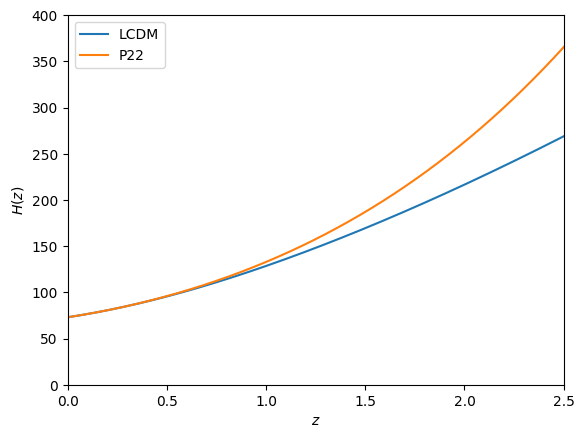

In [93]:
plt.plot(z, H0*Ez(z, [H0, Om]), label='LCDM')
#plt.plot(z, H0*EzP21(z, [H0, q0, j0]), label='P21')
plt.plot(z, H0*EzP22(z, [H0, q0, j0, s0]), label='P22')
#plt.plot(z, EzP31(z, [H0, q0, j0, s0]), label='P31')
plt.plot()
plt.legend()
plt.xlim(0,2.5)
plt.ylim(0,400)
plt.xlabel('$z$')
plt.ylabel('$H (z)$')
plt.show()

In [32]:
def dCP21(z, theta):
    H0, q0, j0 = theta
    
    a1 = 1/H0
    a2 = (1 -2 * j0 + 2 * q0 + 3 * (q0 ** 2))/(6*H0*(1 + q0))
    b1 = (2 -j0 + 4 * q0 + 3 * (q0 ** 2))/(3*(1 + q0))

    dc = (a1*z+a2*z**2)/(1+b1*z)

    return c*dc

def dCP22(z, theta):
    H0, q0, j0, s0 = theta
    
    a1 = 1/H0
    a2 = ((-1 + 5 * j0 -3 * q0 + 6 * j0 * q0 -8 * (q0 ** 2) -6 * (q0 ** 3) + s0)) / (2*H0*((-1 + 2 * j0 -2 * q0 -3 * (q0 ** 2))))
    b1 = ((-2 + 7 * j0 -6 * q0 + 8 * j0 * q0 -13 * (q0 ** 2) -9 * (q0 ** 3) + s0)) /(2*(-1 + 2 * j0 -2 * q0 -3 * (q0 ** 2)))
    b2 = (2 -11 * j0 -4 * (j0 ** 2) + 8 * q0 -25 * j0 * q0 + 23 * (q0 ** 2) -6 * j0 * (q0 ** 2) + 30 * (q0 ** 3) + 9 * (q0 ** 4) -3 * s0
          -3 * q0 *s0) / (12 -24 * j0 + 24 * q0 + 36 * (q0 ** 2))

    dc = (a1*z + a2*z**2)/(1+b1*z+b2*z**2)
    
    return c*dc

def dCP31(z, theta):
    H0, q0, j0, s0 = theta

    a1 = 1/H0
    a2 = ((-2 + 7 * j0 -6 * q0 + 8 * j0 * q0 -13 * (q0 ** 2) -9 * (q0 **3) + s0))/(4*H0*(-2 + j0 -4 * q0 -3 * (q0 ** 2)))
    a3 = ((2 -11 * j0 -4 * (j0 ** 2) + 8 * q0 -25 * j0 * q0 + 23 * (q0 ** 2) -6 * j0 * (q0 ** 2) + 30 * (q0 ** 3) + 9 * (q0 **4)
          -3 * s0 -3 * q0 * s0)) /(24*H0*(-2 + j0 -4 * q0 -3 * (q0 ** 2)))
    b1 = ((-6 + 9 * j0 -18 * q0 + 10 * j0 * q0 -27 * (q0 ** 2) -15 *(q0 ** 3) + s0)) / (4*(-2 + j0 -4 * q0 -3 * (q0 ** 2)))

    dc = (a1*z + a2*z**2 + a3*z**3)/(1 + b1*z)

    return c*dc

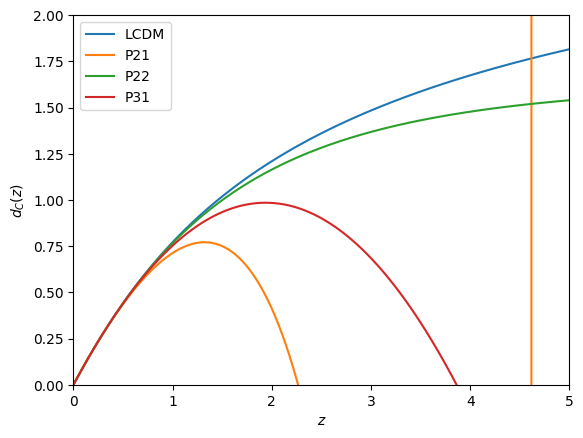

In [35]:
plt.plot(z, (H0/c)*DcLCDM(z, [H0, Om]), label='LCDM')
plt.plot(z, (H0/c)*dCP21(z, [H0, q0, j0]), label='P21')
plt.plot(z, (H0/c)*dCP22(z, [H0, q0, j0, s0]), label='P22')
plt.plot(z, (H0/c)*dCP31(z, [H0, q0, j0, s0]), label='P31')
plt.legend()
plt.xlim(0,5)
plt.ylim(0,2)
plt.xlabel('$z$')
plt.ylabel('$d_C (z)$')
#plt.savefig('HzTeste_NoP22.jpg')
plt.show()

Testando o modelo P22 com parâmetros fiduciais...


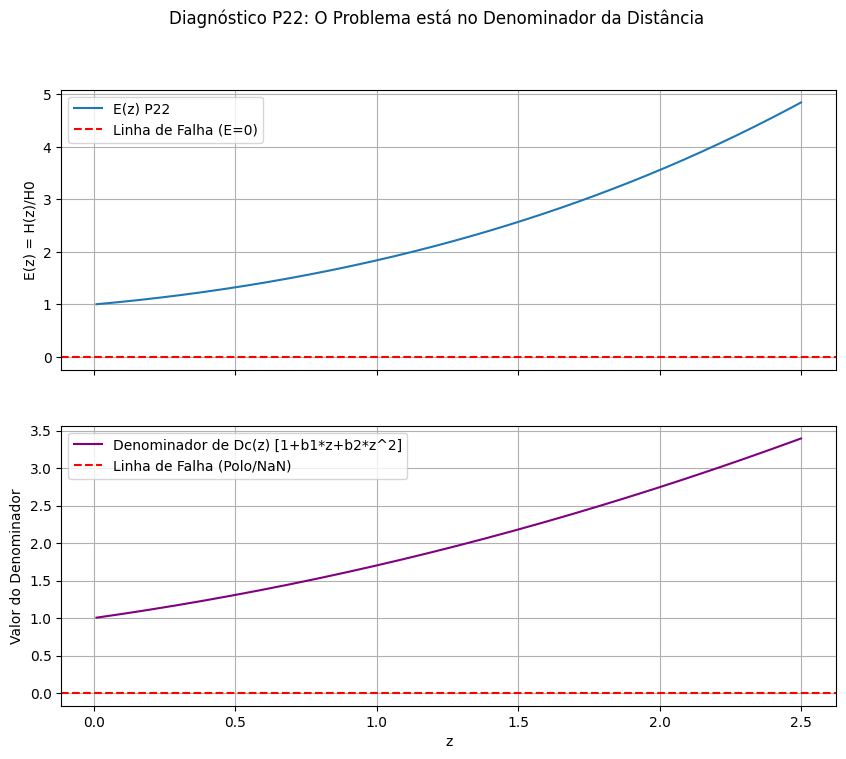


--- SUCESSO ---
O modelo parece ser físico neste intervalo.


In [94]:
import numpy as np
import matplotlib.pyplot as plt

# ================================================================
# COPIE E COLE SUAS FUNÇÕES EXATAS AQUI
# ================================================================
# EzP22
# DcModelP22
# ... (cole-as aqui) ...

def EzP22(z, theta):
    M, H0, q0, j0, s0 = theta
    
    a1 = 1/H0
    a2 = ((-1 + 5 * j0 -3 * q0 + 6 * j0 * q0 -8 * (q0 ** 2) -6 * (q0 ** 3) + s0)) / (2*H0*((-1 + 2 * j0 -2 * q0 -3 * (q0 ** 2))))
    b1 = ((-2 + 7 * j0 -6 * q0 + 8 * j0 * q0 -13 * (q0 ** 2) -9 * (q0 ** 3) + s0)) /(2*(-1 + 2 * j0 -2 * q0 -3 * (q0 ** 2)))
    b2 = (2 -11 * j0 -4 * (j0 ** 2) + 8 * q0 -25 * j0 * q0 + 23 * (q0 ** 2) -6 * j0 * (q0 ** 2) + 30 * (q0 ** 3) + 9 * (q0 ** 4) -3 * s0
          -3 * q0 *s0) / (12 -24 * j0 + 24 * q0 + 36 * (q0 ** 2))

    denom_Hz = a1 + 2*a2*z + (a2*b1 - a1*b2)*z**2
    num_Hz = (1 + b1 * z + b2 * (z ** 2)) ** 2
    hz = num_Hz / denom_Hz
    
    return hz/H0

def DcModelP22(z, theta):
    M, H0, q0, j0, s0 = theta
    
    a1 = 1/H0
    a2 = ((-1 + 5 * j0 -3 * q0 + 6 * j0 * q0 -8 * (q0 ** 2) -6 * (q0 ** 3) + s0)) / (2*H0*((-1 + 2 * j0 -2 * q0 -3 * (q0 ** 2))))
    b1 = ((-2 + 7 * j0 -6 * q0 + 8 * j0 * q0 -13 * (q0 ** 2) -9 * (q0 ** 3) + s0)) /(2*(-1 + 2 * j0 -2 * q0 -3 * (q0 ** 2)))
    b2 = (2 -11 * j0 -4 * (j0 ** 2) + 8 * q0 -25 * j0 * q0 + 23 * (q0 ** 2) -6 * j0 * (q0 ** 2) + 30 * (q0 ** 3) + 9 * (q0 ** 4) -3 * s0
          -3 * q0 *s0) / (12 -24 * j0 + 24 * q0 + 36 * (q0 ** 2))

    dc = (a1*z + a2*z**2)/(1+b1*z+b2*z**2)
    
    return dc

# ================================================================
# FIM DAS SUAS FUNÇÕES
# ================================================================

# Seus parâmetros fiduciais
par0_22 = [-19.2, 73.03398760350208, -0.5280171275112104, 1, -0.35]

# Grid de Redshift (cobrindo dados de CC e SNe, ex: até z=2.3)
z_grid = np.linspace(0.01, 2.5, 200)

print("Testando o modelo P22 com parâmetros fiduciais...")

# --- Extrair coeficientes para plotar o denominador ---
M, H0, q0, j0, s0 = par0_22
b1 = ((-2 + 7 * j0 -6 * q0 + 8 * j0 * q0 -13 * (q0 ** 2) -9 * (q0 ** 3) + s0)) /(2*(-1 + 2 * j0 -2 * q0 -3 * (q0 ** 2)))
b2 = (2 -11 * j0 -4 * (j0 ** 2) + 8 * q0 -25 * j0 * q0 + 23 * (q0 ** 2) -6 * j0 * (q0 ** 2) + 30 * (q0 ** 3) + 9 * (q0 ** 4) -3 * s0
      -3 * q0 *s0) / (12 -24 * j0 + 24 * q0 + 36 * (q0 ** 2))

# Este é o termo problemático
denom_Dc = 1 + b1*z_grid + b2*z_grid**2
# --- Fim da extração ---

E_z = EzP22(z_grid, par0_22)
Dc_z = DcModelP22(z_grid, par0_22)

# --- Plotar ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Plot 1: E(z) (que você disse que parece bom)
ax1.plot(z_grid, E_z, label=f'E(z) P22')
ax1.set_ylabel('E(z) = H(z)/H0')
ax1.axhline(0, color='red', linestyle='--', label='Linha de Falha (E=0)')
ax1.legend(); ax1.grid(True)

# Plot 2: O DENOMINADOR de Dc(z) (O VERDADEIRO PROBLEMA)
ax2.plot(z_grid, denom_Dc, label=f'Denominador de Dc(z) [1+b1*z+b2*z^2]', color='purple')
ax2.set_xlabel('z'); ax2.set_ylabel('Valor do Denominador')
ax2.axhline(0, color='red', linestyle='--', label='Linha de Falha (Polo/NaN)')
ax2.legend(); ax2.grid(True)

plt.suptitle('Diagnóstico P22: O Problema está no Denominador da Distância')
plt.show()

# Verificar numericamente
if np.any(denom_Dc <= 0):
    print("\n>>> FALHA CONFIRMADA NA DISTÂNCIA <<<")
    print(f"O denominador de Dc(z) torna-se negativo ou zero!")
    z_falha = z_grid[denom_Dc <= 0][0]
    print(f"A falha (que causa NaN no log10) começa em z approx = {z_falha:.3f}")
else:
    print("\n--- SUCESSO ---")
    print("O modelo parece ser físico neste intervalo.")